In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm
import xarray as xr
import mne

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# Load HGA

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

100%|██████████| 2254/2254 [00:16<00:00, 136.73it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [ ]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 472320
PIC electrode count: 417344


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [6]:
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
HGAs[['x','y','z']] = HGAs[['x','y','z']].values + translation

# Load ZSCORE

In [7]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
ZAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    ZAs.append(df)

ZAs = pd.concat(ZAs)

# rename both phase : Resp and Response to Resp
ZAs.loc[ZAs.phase == 'Resp', 'phase'] = 'Response'
ZAs.loc[ZAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
ZAs['phase'] = ZAs['phase'].str.lower()

# rename INS to 'Insula'
ZAs.loc[ZAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
ZAs.loc[ZAs.roi == 'PrG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'PoG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'Subcentral', 'roi'] = 'SMC'


ZAs.loc[ZAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
ZAs.loc[ZAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
ZAs.loc[ZAs.roi=='CG', 'roi'] = 'ACC'
ZAs.head()

100%|██████████| 1214/1214 [00:33<00:00, 35.77it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [8]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
ZAs['roi'] = ZAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(ZAs[ZAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(ZAs[ZAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = ZAs[ZAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
ZAs.head()

AIC electrode count: 1052800
PIC electrode count: 876160


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [9]:
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
ZAs[['x','y','z']] = ZAs[['x','y','z']].values + translation

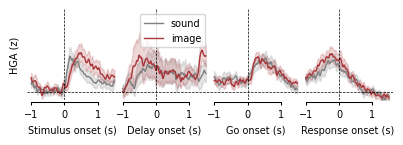

In [17]:
rois = ['AIC']

# tasks = ['LexicalDelay', 'LexicalNoDelay']

tasks = ['PictureNaming']
descs = ['Passive', 'Repeat']

colors = ['gray', red]
modality = ['sound','image']

subset = HGAs[
    (HGAs.task.isin(tasks))
    & (HGAs.roi.isin(rois))
    # & (HGAs.hemi == 'L')
    # & (HGAs.description.isin(['Decision']))
    & (HGAs.modality.isin(modality))
    & (HGAs.subject!='D0121')
]

subset_z = ZAs[
    (ZAs.task.isin(tasks))
    & (ZAs.channel.isin(subset.channel.unique()))
    # & (ZAs.hemi == 'L')
    & (ZAs.time<1.5)
    & (ZAs.description.isin(descs))
    & (ZAs.modality.isin(modality))
]

phases = ['stimulus', 'delay', 'go' ,'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='modality',
        hue_order=modality,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)
    
# plt.suptitle(f'PictureNaming-AIC-{modality}', fontsize=9)
# plt.savefig(f'grantfig/aim1_compare_action_{rois[0]}_lexical_{modality}.svg', dpi=300, bbox_inches='tight')
plt.show()

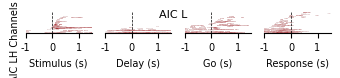

In [19]:
import xarray as xr

roi = 'AIC'
hemi = 'L'
cmap=reds
phases = ['stimulus', 'delay', 'go', 'response']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality == 'sound')
    & (HGAs.hemi == hemi)
    & (HGAs.task.isin(tasks))
    & (HGAs.roi == roi)
]

agg_data = subset.groupby(['channel', 'time', 'phase']).agg({
    'value': 'mean',
    'mask': lambda x: x.any()
}).reset_index()

agg_data.loc[~agg_data['mask'], 'value'] = np.nan

max_channels = 0
phase_channel_map = {}
for phase in phases:
    phase_data = agg_data[agg_data.phase == phase]
    sig_channels = phase_data[phase_data['mask'] == True]['channel'].unique()
    first_sig_times = []
    for ch in sig_channels:
        ch_data = phase_data[phase_data.channel == ch]
        sig_times = ch_data[ch_data['mask'] == True]['time'].values
        if len(sig_times) > 0:
            first_sig_times.append((ch, sig_times.min()))
        else:
            first_sig_times.append((ch, np.inf))
    sorted_channels = [ch for ch, _ in sorted(first_sig_times, key=lambda x: x[1])]
    phase_channel_map[phase] = sorted_channels
    max_channels = max(max_channels, len(sorted_channels))

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5*len(phases)*cm, float(0.02*max_channels*cm)))

for ax, phase in zip(axes, phases):
    sorted_channels = phase_channel_map[phase]
    phase_data = agg_data[agg_data.phase == phase]
    
    if len(sorted_channels) == 0:
        ax.text(0.5, 0.5, 'No significant\nchannels', 
                ha='center', va='center', transform=ax.transAxes, fontsize=7)
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(0, max_channels)
        continue
    
    phase_data_filtered = phase_data[phase_data.channel.isin(sorted_channels)]
    pivot_data = phase_data_filtered.pivot(index='channel', columns='time', values='value')
    pivot_data = pivot_data.reindex(index=sorted_channels)
    
    da = xr.DataArray(
        pivot_data.values,
        coords={'channel': pivot_data.index, 'time': pivot_data.columns},
        dims=['channel', 'time']
    )
    
    time_values = da.coords['time'].values.astype(float)
    if len(time_values) > 1:
        step = np.diff(time_values).mean()
    else:
        step = 0.01  # fallback for single time point
    time_edges = np.concatenate(([time_values[0] - step/2], time_values[:-1] + step/2, [time_values[-1] + step/2]))
    channel_edges = np.arange(len(sorted_channels) + 1)
    
    # Build meshgrid for pcolormesh
    T, C = np.meshgrid(time_edges, channel_edges)
    
    im = ax.pcolormesh(T, C, da.values, cmap=cmap, vmin=0, vmax=1.5, shading='auto', rasterized=True)
    
    sns.despine(ax=ax, offset=0, trim=False)
    ax.spines['left'].set_visible(False)
    # fixed ticks at -1, 0, 1
    ax.set_xticks([-1, 0, 1])
    ax.set_xticklabels(['-1','0', '1'], fontsize=7)
    
    ax.set_yticks([])
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, max_channels)
    
    if ax == axes[0]:
        ax.set_ylabel(f'{roi} {hemi}H Channels (n={len(sorted_channels)})', fontsize=7)
    else:
        ax.set_ylabel(f'', fontsize=7)

plt.suptitle(f'{roi} {hemi}', fontsize=8)
# plt.savefig(f'grantfig/aims1_heatmap_{roi}_{hemi}_channels.svg',dpi=300,bbox_inches='tight')
plt.show()

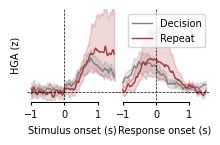

In [ ]:
rois = ['AIC']

tasks = ['LexicalNoDelay']

descs = ['Passive', 'Repeat']

colors = ['gray', red]
modality = ['sound']
description = ['Decision','Repeat']
subset = HGAs[
    (HGAs.task.isin(tasks))
    & (HGAs.roi.isin(rois))
    # & (HGAs.hemi == 'L')
    & (HGAs.description.isin(description))
    & (HGAs.modality.isin(modality))
    & (HGAs.subject!='D0121')
]

subset_z = ZAs[
    (ZAs.task.isin(tasks))
    & (ZAs.channel.isin(subset.channel.unique()))
    # & (ZAs.hemi == 'L')
    & (ZAs.time<1.5)
    & (ZAs.description.isin(descs))
    & (ZAs.modality.isin(modality))
]

phases = ['stimulus' ,'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='description',
        hue_order=description,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)
    
# plt.suptitle(f'PictureNaming-AIC-{modality}', fontsize=9)
# plt.savefig(f'grantfig/aim1_compare_action_{rois[0]}_lexical_{modality}.svg', dpi=300, bbox_inches='tight')
plt.show()